# Previsão e Análise de Temperatura - Campinas (5 Dias)
Este notebook busca os dados de 5 dias (com uma previsão a cada 3 horas) diretamente da API do OpenWeatherMap, sem precisar do banco de dados.

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
import os

# 1. Carregar a API_KEY do arquivo .env
env_path = Path('../config/.env')
load_dotenv(env_path)
API_KEY = os.getenv("API_KEY")

# 2. Fazer requisição para a API de PREVISÃO do Tempo (endpoint 'forecast' traz 5 dias)
url = f'https://api.openweathermap.org/data/2.5/forecast?q=Campinas,br&units=metric&lang=pt_br&appid={API_KEY}'
response = requests.get(url)
data = response.json()

# 3. Processar e organizar os dados em uma Tabela (DataFrame)
records = []
for item in data.get('list', []):
    records.append({
        'Data e Hora': item['dt_txt'],
        'Temperatura (C)': item['main']['temp'],
        'Temp. Minima (C)': item['main']['temp_min'],
        'Temp. Maxima (C)': item['main']['temp_max'],
        'Umidade (%)': item['main']['humidity'],
        'Clima': item['weather'][0]['description'].capitalize()
    })

df = pd.DataFrame(records)
df['Data e Hora'] = pd.to_datetime(df['Data e Hora'])
df['Data'] = df['Data e Hora'].dt.date

# 4. Análise: Resumo por DIA (Máxima e Mínima do dia)
df_diario = df.groupby('Data').agg(
    Temp_Minima=('Temp. Minima (C)', 'min'),
    Temp_Maxima=('Temp. Maxima (C)', 'max')
).reset_index()

print("==========================================")
print("RESUMO DIÁRIO DE TEMPERATURAS - CAMPINAS")
print("==========================================")
display(df_diario)

print("\n==========================================")
print("AMOSTRA DOS DADOS COMPLETOS (A CADA 3 HORAS)")
print("==========================================")
display(df.head(8))  # Exibe 1 dia completo de medidas


Matplotlib is building the font cache; this may take a moment.


RESUMO DIÁRIO DE TEMPERATURAS - CAMPINAS


,Data,Temp_Minima,Temp_Maxima
0,2026-04-26,26.85,29.87
1,2026-04-27,17.49,29.15
2,2026-04-28,18.85,29.75
3,2026-04-29,18.64,29.80
4,2026-04-30,19.95,27.44
5,2026-05-01,16.80,27.71



AMOSTRA DOS DADOS COMPLETOS (A CADA 3 HORAS)


,Data e Hora,Temperatura (C),Temp. Minima (C),Temp. Maxima (C),Umidade (%),Clima,Data
0,2026-04-26 18:00:00,28.55,28.55,29.87,49,Céu limpo,2026-04-26
1,2026-04-26 21:00:00,27.20,26.85,27.20,55,Céu limpo,2026-04-26
2,2026-04-27 00:00:00,22.99,22.99,22.99,60,Nuvens dispersas,2026-04-27
3,2026-04-27 03:00:00,21.55,21.55,21.55,68,Nuvens dispersas,2026-04-27
4,2026-04-27 06:00:00,20.38,20.38,20.38,73,Nuvens dispersas,2026-04-27
5,2026-04-27 09:00:00,17.49,17.49,17.49,76,Nublado,2026-04-27
6,2026-04-27 12:00:00,22.73,22.73,22.73,63,Nublado,2026-04-27
7,2026-04-27 15:00:00,27.90,27.90,27.90,47,Nuvens dispersas,2026-04-27


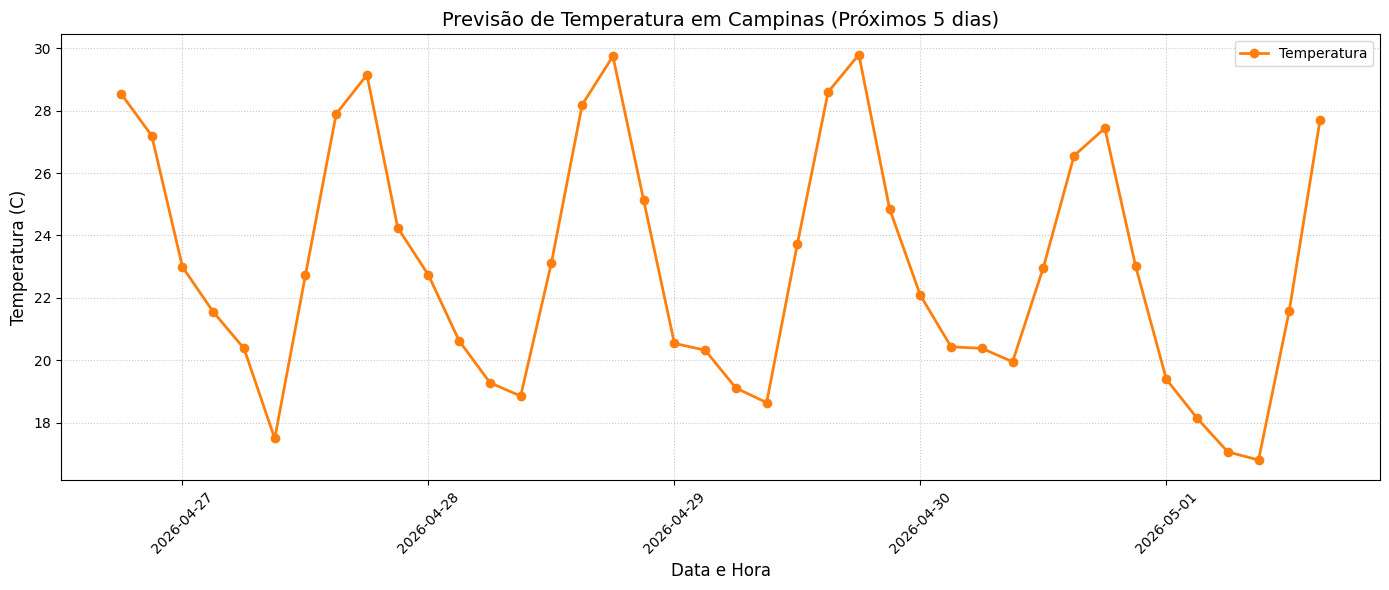

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df['Data e Hora'], df['Temperatura (C)'], marker='o', color='#ff7f0e', label='Temperatura', linewidth=2)

plt.title('Previsão de Temperatura em Campinas (Próximos 5 dias)', fontsize=14)
plt.xlabel('Data e Hora', fontsize=12)
plt.ylabel('Temperatura (C)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
